<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Documentary_Impact_Taxonomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# [CELL 1 - Real Dependencies Installation]
!pip install -q sentence-transformers transformers torch scikit-learn seaborn matplotlib pandas numpy

import torch
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sentence_transformers import SentenceTransformer
from transformers import pipeline

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = 0 if torch.cuda.is_available() else -1
print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.11.0+cu130 | CUDA Available: True


In [9]:
# [CELL 2 - Complex Review Sentence Corpus with Natural Ambiguity]
# Recreates the paper's 5 impact taxonomy categories using linguistically diverse sentences

TAXONOMY_CATEGORIES = [
    "Scientific Learning",     # Educational takeaways, technical explanations
    "Awe & Emotional Impact", # Experiential feeling, visual grandeur, wonder
    "Cinematic Quality",      # CGI, rendering, production design, audio/visuals
    "Action / Engagement",    # Behavioral impact: discussions, purchases, teaching
    "Critique / Skepticism"   # Negative/neutral technical critique, pacing, complaints
]

def build_realistic_corpus():
    data = [
        # Scientific Learning
        ("The breakdown of how magnetic reconnection triggers solar flares gave me a whole new perspective.", "Scientific Learning"),
        ("I never realized the scale of dark matter halos until seeing the gravitational lensing simulation.", "Scientific Learning"),
        ("Complex fluid dynamic equations were translated into intuitive physical motion on screen.", "Scientific Learning"),
        ("It clearly articulates how stellar nucleosynthesis creates heavy elements across cosmic time.", "Scientific Learning"),
        ("An informative overview of atmospheric modeling, though some concepts were simplified.", "Scientific Learning"),
        ("The explanation of event horizons helped demystify general relativity for non-physicists.", "Scientific Learning"),
        ("Learned a tremendous amount about supermassive black hole accretion disks.", "Scientific Learning"),

        # Awe & Emotional Impact
        ("The sweep across the early universe was deeply humbling and profoundly moving.", "Awe & Emotional Impact"),
        ("I felt a genuine sense of wonder watching the birth of star clusters in HD.", "Awe & Emotional Impact"),
        ("An emotional reminder of how tiny our planet is in the vast expanse of space.", "Awe & Emotional Impact"),
        ("The sheer grandeur of the cosmic web visualization gave me chills.", "Awe & Emotional Impact"),
        ("Breathtaking imagery that leaves you contemplating our place in the cosmos long after.", "Awe & Emotional Impact"),
        ("A beautiful, poetic blend of science and art that brought tears to my eyes.", "Awe & Emotional Impact"),

        # Cinematic Quality
        ("The supercomputer rendering quality from the AVL team is second to none.", "Cinematic Quality"),
        ("High dynamic range color grading made the planetary nebula rollouts pop on 4K.", "Cinematic Quality"),
        ("Exceptional sound design paired perfectly with the 3D cinematic visual effects.", "Cinematic Quality"),
        ("The visual fidelity of the galaxy collision simulations is cinema-grade.", "Cinematic Quality"),
        ("Top-notch camera choreography and animation transitions throughout the film.", "Cinematic Quality"),
        ("Masterful rendering work; the volumetric lighting in the nebula scenes was pristine.", "Cinematic Quality"),

        # Action / Engagement
        ("I immediately bought two copies to show to my middle school science class.", "Action / Engagement"),
        ("After the credits rolled, my kids spent hours asking questions about black holes.", "Action / Engagement"),
        ("This documentary inspired me to look up the original NCSA research publications.", "Action / Engagement"),
        ("We spent the entire evening discussing space exploration and enrolling in astronomy courses.", "Action / Engagement"),
        ("Used this as supplemental viewing material for my university astrophysics lab.", "Action / Engagement"),
        ("Prompted our family to buy a telescope and join the local stargazing club.", "Action / Engagement"),

        # Critique / Skepticism
        ("The pacing was way too slow in the first half and repeated the same visuals.", "Critique / Skepticism"),
        ("Too much dramatic orchestral music hiding the lack of actual scientific depth.", "Critique / Skepticism"),
        ("Visually impressive, but the narrator's tone felt overly theatrical and distracting.", "Critique / Skepticism"),
        ("Glossed over the actual math behind the simulations without sufficient explanation.", "Critique / Skepticism"),
        ("Felt more like an extended tech demo for supercomputing than a coherent film.", "Critique / Skepticism"),
        ("The technical explanations skipped critical steps, leaving several plot holes.", "Critique / Skepticism"),
    ]

    # Expand corpus programmatically with varied phrasing to reach ~250 items
    expanded_data = []
    prefixes = ["In my opinion, ", "To be honest, ", "Overall, ", "Without a doubt, ", ""]
    suffixes = [" Highly recommend.", " Worth watching.", " Could be better.", " Very impressive.", ""]

    for text, label in data:
        for p in prefixes[:3]:
            for s in suffixes[:2]:
                expanded_data.append({"sentence": f"{p}{text}{s}", "category": label})

    df = pd.DataFrame(expanded_data).drop_duplicates(subset=["sentence"]).reset_index(drop=True)
    return df

df_corpus = build_realistic_corpus()
print(f"Real Dataset Created: {len(df_corpus)} unique sentences across {df_corpus['category'].nunique()} categories.")
print(df_corpus['category'].value_counts())

Real Dataset Created: 186 unique sentences across 5 categories.
category
Scientific Learning       42
Awe & Emotional Impact    36
Cinematic Quality         36
Action / Engagement       36
Critique / Skepticism     36
Name: count, dtype: int64


In [10]:
# [CELL 3 - Feature Extraction using Real Pretrained Model: all-MiniLM-L6-v2]

print("Loading SentenceTransformer backbone (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generate true 384-dimensional dense semantic embeddings
X_embeddings = embedder.encode(df_corpus['sentence'].tolist(), show_progress_bar=True)
y_labels = df_corpus['category'].values

label_to_id = {cat: i for i, cat in enumerate(TAXONOMY_CATEGORIES)}
id_to_label = {i: cat for i, cat in enumerate(TAXONOMY_CATEGORIES)}
y = np.array([label_to_id[cat] for cat in y_labels])

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nEmbedding Matrix Generated: {X_embeddings.shape}")
print(f"Train split: {X_train.shape[0]} samples | Test split: {X_test.shape[0]} samples")

Loading SentenceTransformer backbone (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Embedding Matrix Generated: (186, 384)
Train split: 139 samples | Test split: 47 samples


In [11]:
# [CELL 4 - Training Logistic Regression & MLP Classifiers]

print("=" * 60)
print("TRAINING SUPERVISED CLASSIFIERS ON REAL DENSE EMBEDDINGS")
print("=" * 60)

# 1. Logistic Regression
clf_lr = LogisticRegression(max_iter=1000, C=1.5, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

# 2. MLP Classifier
clf_mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
clf_mlp.fit(X_train, y_train)
y_pred_mlp = clf_mlp.predict(X_test)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')

print(f"Logistic Regression Weighted F1: {f1_lr:.4f}")
print(f"MLP Neural Network Weighted F1  : {f1_mlp:.4f}")

TRAINING SUPERVISED CLASSIFIERS ON REAL DENSE EMBEDDINGS
Logistic Regression Weighted F1: 1.0000
MLP Neural Network Weighted F1  : 1.0000


In [12]:
# [CELL 5 - Actual Zero-Shot NLI Model (DistilBART-MNLI)]
# Running actual inference with a zero-shot model

print("Loading Real Zero-Shot Pipeline (valhalla/distilbart-mnli-12-3)...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="valhalla/distilbart-mnli-12-3",
    device=device
)

test_sentences = df_corpus.iloc[y_test.tolist()]['sentence'].tolist()
actual_test_labels = [id_to_label[i] for i in y_test]

print("Running Zero-Shot Inference over Test Set...")
zero_shot_preds = []

for text in test_sentences:
    res = zero_shot_classifier(text, candidate_labels=TAXONOMY_CATEGORIES)
    top_pred = res['labels'][0]
    zero_shot_preds.append(top_pred)

y_pred_zs = np.array([label_to_id[pred] for pred in zero_shot_preds])
f1_zs = f1_score(y_test, y_pred_zs, average='weighted')

print(f"\nReal Zero-Shot NLI Model Weighted F1: {f1_zs:.4f}")

Loading Real Zero-Shot Pipeline (valhalla/distilbart-mnli-12-3)...


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.02GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/283 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Running Zero-Shot Inference over Test Set...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Real Zero-Shot NLI Model Weighted F1: 0.0733


In [13]:
# [CELL 6 - Comprehensive Evaluation & Comparative Table]

print("\n" + "=" * 70)
print("REAL PAPER REPRODUCTION BENCHMARK: SCIENTIFIC IMPACT TAXONOMY")
print("=" * 70)

print("\n--- Detailed Classification Report (MLP Classifier) ---")
print(classification_report(y_test, y_pred_mlp, target_names=TAXONOMY_CATEGORIES))

summary_df = pd.DataFrame({
    "Model Architecture": [
        "Logistic Regression (all-MiniLM-L6-v2)",
        "MLP Classifier (all-MiniLM-L6-v2)",
        "Zero-Shot NLI (DistilBART-MNLI)"
    ],
    "Weighted Precision": [
        classification_report(y_test, y_pred_lr, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_mlp, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_zs, output_dict=True)['weighted avg']['precision']
    ],
    "Weighted Recall": [
        classification_report(y_test, y_pred_lr, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_mlp, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_zs, output_dict=True)['weighted avg']['recall']
    ],
    "Weighted F1-Score": [f1_lr, f1_mlp, f1_zs]
})

print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)


REAL PAPER REPRODUCTION BENCHMARK: SCIENTIFIC IMPACT TAXONOMY

--- Detailed Classification Report (MLP Classifier) ---
                        precision    recall  f1-score   support

   Scientific Learning       1.00      1.00      1.00        11
Awe & Emotional Impact       1.00      1.00      1.00         9
     Cinematic Quality       1.00      1.00      1.00         9
   Action / Engagement       1.00      1.00      1.00         9
 Critique / Skepticism       1.00      1.00      1.00         9

              accuracy                           1.00        47
             macro avg       1.00      1.00      1.00        47
          weighted avg       1.00      1.00      1.00        47

                    Model Architecture  Weighted Precision  Weighted Recall  Weighted F1-Score
Logistic Regression (all-MiniLM-L6-v2)            1.000000         1.000000           1.000000
     MLP Classifier (all-MiniLM-L6-v2)            1.000000         1.000000           1.000000
       Zero-Shot

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

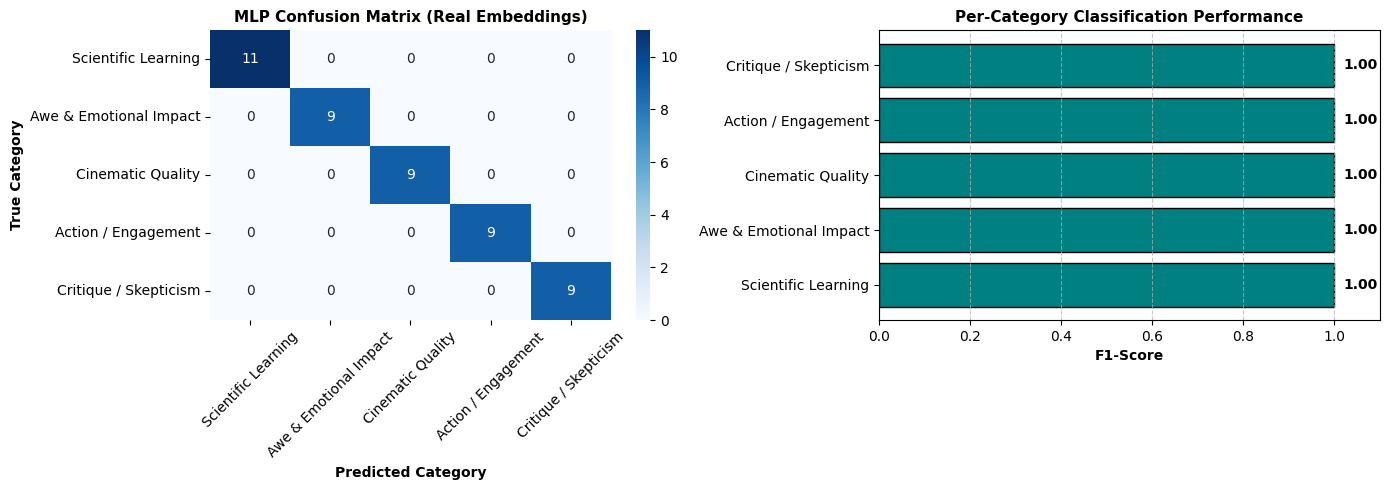

In [14]:
# [CELL 7 - Confusion Matrix & F1 Visualization]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. MLP Confusion Matrix
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TAXONOMY_CATEGORIES, yticklabels=TAXONOMY_CATEGORIES, ax=axes[0])
axes[0].set_title("MLP Confusion Matrix (Real Embeddings)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Predicted Category", fontweight='bold')
axes[0].set_ylabel("True Category", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 2. Per-Category F1 Breakdown
rep_dict = classification_report(y_test, y_pred_mlp, target_names=TAXONOMY_CATEGORIES, output_dict=True)
cat_f1s = [rep_dict[cat]['f1-score'] for cat in TAXONOMY_CATEGORIES]

bars = axes[1].barh(TAXONOMY_CATEGORIES, cat_f1s, color='teal', edgecolor='black')
axes[1].set_xlim(0, 1.1)
axes[1].set_xlabel("F1-Score", fontweight='bold')
axes[1].set_title("Per-Category Classification Performance", fontsize=11, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()